$\Huge \text{SESSION-4}$  
●	Monte Carlo Methods  
●	Temporal Difference (TD) Learning  
●	Q-Learning  
●	Function Approximation  

Problem Statement - Design a custom 5×5 maze and train a Q-learning agent to find the path from Start (S) to Goal (G).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# S - starting point
# G - goal point
maze = np.array([
    ["S","0","1","0","0"],
    ["0","1","0","1","0"],
    ["0","0","0","1","0"],
    ["1","1","0","0","0"],
    ["0","0","0","1","G"],
])
# number of unique positions that the agent can take - 5x5
n_states = maze.size

In [ ]:
# unit vectors along the allowed paths - up, down, left, right
actions = {
    0 : (0,1), # up
    1 : (0,-1), # down
    2 : (-1,0), # left
    3 : (1,0) # right
}
n_actions = len(actions)

In [ ]:
start = None
goal = None
cnt = 0
for i in range(5):
  for j in range(5):
    if maze[i][j]=="S": start = (i,j)
    if maze[i][j]=="G": goal = (i,j)

In [ ]:
# checking if a position/state is within the bounds of our environment
def inside_grid(x, y):
  return 0<=x<maze.shape[0] and 0<=y<maze.shape[1]

# simulating rewards for steps taken by the agent
def step(action, state):
  x_i, y_i = state # position before taking the step
  dx, dy = actions[action] # unit vectors along the direction of the step
  x_f, y_f = x_i+dx, y_i+dy # position after taking the step


  # if the agent exits the environment bounds, it incurs a reward of -100,
  # a reward of -10 if it hits a wall,
  # a reward of +100 if it reaches the goal, and
  # a reward of -1 otherwise

  # the function returns final_state, reward, done
  # where done is a boolean that tells whether the agent has hit the goal or not
  if not inside_grid(x_f,y_f): return (x_i,y_i), -100, False
  elif maze[x_f][y_f]=="1": return (x_i,y_i), -10, False
  elif((x_f,y_f)==goal): return (x_f,y_f), 100, True
  else: return (x_f,y_f), -1, False

In [ ]:
# hyperparameters
alpha = 0.7
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.1
epsilon_decay = 0.995
episodes = 5000
max_steps = 100

In [ ]:
Q = np.zeros((n_states, n_actions)) # initializing the Q-table
rng = np.random.default_rng(0) # random number generator

In [ ]:
rewards_per_episode = []

for ep in range(episodes):
  start_state = start
  total_reward = 0

  for t in range(max_steps):
    # converting the state coordinates into an index that
    # corresponds to the state's position in the Q-table
    state_id = start_state[0]*maze.shape[1]+start_state[1]

    # ε-greedy exploration
    if np.random.uniform(0,1) < epsilon:
      action = rng.integers(0, n_actions)
    else:
      action = np.argmax(Q[state_id])


    next_state, reward, done = step(action, start_state)
    next_state_id = next_state[0]*maze.shape[1]+next_state[1]

    # updating Q-values according to Q(s,a)←Q(s,a)+α[r+γmax a′Q(s′,a′)−Q(s,a)]
    Q[state_id, action] += alpha*(
        reward + gamma * np.max(Q[next_state_id]) - Q[state_id, action]
    )

    start_state = next_state
    total_reward += reward

    if done:
      break

  # epsilon decay, where epsilon_min is the lower bound on epsilon
  epsilon = max(epsilon_min, epsilon * epsilon_decay)
  rewards_per_episode.append(total_reward)

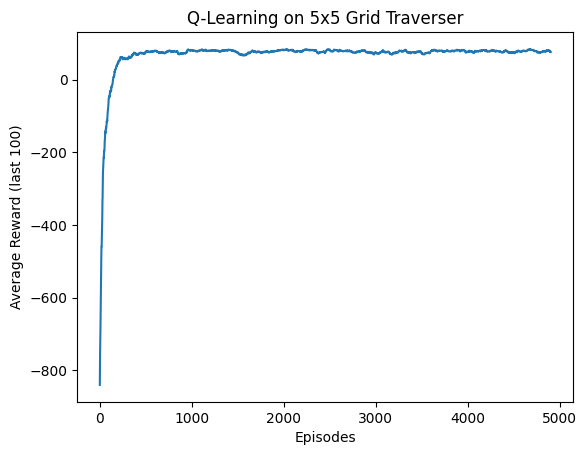

In [ ]:
plt.plot(np.convolve(rewards_per_episode, np.ones(100)/100, mode = 'valid'))
plt.xlabel("Episodes")
plt.ylabel("Average Reward (last 100)")
plt.title("Q-Learning on 5x5 Grid Traverser")
plt.show()

As expected the agent incurs heavy negative reward at start.   
But as the episodes go on, the agent learns and accumulates a positive reward.  
It converges rather quicky, attaining the maximum around 500th episode.

In [ ]:
# storing the learned path in an array, to facilitate its plotting
def learned_path(start_state, max_len=100):
    path = [start_state]
    s = start_state
    for _ in range(max_len):
        if s == goal:
            break
        s_id = s[0]*maze.shape[1]+s[1]

        action = int(np.argmax(Q[s_id]))
        next_state, _, _ = step(action, s)
        if next_state == s:
            break
        path.append(next_state)
        s = next_state
    return path

path = learned_path(start)


In [ ]:
print("Start:", start, " Goal:", goal)
print("Learned path length:", len(path))
print("Path:")
print(path)

Start: (0, 0)  Goal: (4, 4)
Learned path length: 9
Path:
[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4)]


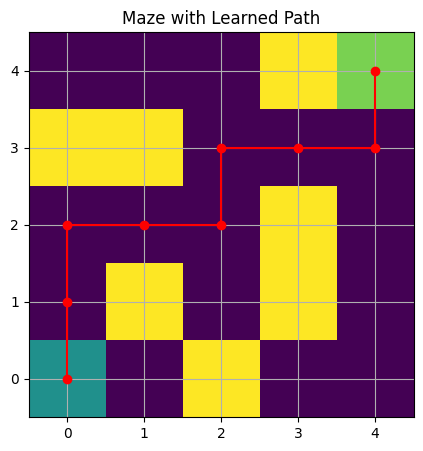

In [ ]:
disp = maze.copy().astype(str)
disp[disp == "S"] = "0"
disp[disp == "G"] = "0"
disp = disp.astype(float)

disp[start] = 0.5
disp[goal] = 0.8

plt.figure(figsize=(5,5))
plt.imshow(disp, interpolation='none')
plt.title("Maze with Learned Path")

ys = [p[1] for p in path]
xs = [p[0] for p in path]
plt.plot(ys, xs, marker='o', color='red')

plt.xticks(range(maze.shape[1]))
plt.yticks(range(maze.shape[0]))
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()